In [114]:
from read_model_runs import read_model_runs

question_long_df, model_wide_df, question_wide_df, firac_order = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)

question_long_df.head()


shape (18, 22)


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,...,prompt,prompt_token_length,A,B,C,D,full_response,full_response_token_length,rule_count,response_time_seconds
0,gemma-3-12b-it,FIRAC,portuguese,True,oab-161.pdf,oab-161.pdf-089,DIREITO CIVIL,V,89,C,...,Resolva a questão juridica abaixo considerando...,528,"modalidade de obrigação facultativa, na qual o...","modalidade de adimplemento direto, na qual o c...","causa extintiva da obrigação, na qual o credor...","modalidade de obrigação alternativa, na qual o...","{\n ""F"": [""O problema jurídico central reside ...",387,2,6.798336
1,gemma-3-12b-it,FIRA_,portuguese,True,oab-161.pdf,oab-161.pdf-089,DIREITO CIVIL,V,89,C,...,Resolva a questão juridica abaixo considerando...,496,"modalidade de obrigação facultativa, na qual o...","modalidade de adimplemento direto, na qual o c...","causa extintiva da obrigação, na qual o credor...","modalidade de obrigação alternativa, na qual o...","{\n ""F"": [""O problema jurídico central reside ...",355,2,5.927094
2,gemma-3-12b-it,FIR__,portuguese,True,oab-161.pdf,oab-161.pdf-089,DIREITO CIVIL,V,89,C,...,Resolva a questão juridica abaixo considerando...,371,"modalidade de obrigação facultativa, na qual o...","modalidade de adimplemento direto, na qual o c...","causa extintiva da obrigação, na qual o credor...","modalidade de obrigação alternativa, na qual o...","{\n ""F"": [""O problema jurídico central reside ...",327,2,5.571865
3,gemma-3-12b-it,FI___,portuguese,False,oab-161.pdf,oab-161.pdf-089,DIREITO CIVIL,V,89,B,...,Resolva a questão juridica abaixo considerando...,285,"modalidade de obrigação facultativa, na qual o...","modalidade de adimplemento direto, na qual o c...","causa extintiva da obrigação, na qual o credor...","modalidade de obrigação alternativa, na qual o...","{\n ""F"": [""O problema jurídico central reside ...",376,2,5.204610
4,gemma-3-12b-it,F____,portuguese,False,oab-161.pdf,oab-161.pdf-089,DIREITO CIVIL,V,89,B,...,Resolva a questão juridica abaixo considerando...,253,"modalidade de obrigação facultativa, na qual o...","modalidade de adimplemento direto, na qual o c...","causa extintiva da obrigação, na qual o credor...","modalidade de obrigação alternativa, na qual o...","{\n ""F"": [""O problema jurídico central reside ...",260,2,4.071393


Existe missing data?

In [115]:
question_long_df.isna().sum()


model_name                    0
firac                         0
language                      0
is_correct                    0
pdf_filename                  0
question_id                   0
materia                       0
oab_test_id                   0
oab_question_id               0
chosen_option                 0
correct_option                0
enunciado                     0
prompt                        0
prompt_token_length           0
A                             0
B                             0
C                             0
D                             0
full_response                 0
full_response_token_length    0
rule_count                    0
response_time_seconds         0
dtype: int64

In [116]:
question_long_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   model_name                  18 non-null     object 
 1   firac                       18 non-null     object 
 2   language                    18 non-null     object 
 3   is_correct                  18 non-null     bool   
 4   pdf_filename                18 non-null     object 
 5   question_id                 18 non-null     object 
 6   materia                     18 non-null     object 
 7   oab_test_id                 18 non-null     object 
 8   oab_question_id             18 non-null     int64  
 9   chosen_option               18 non-null     object 
 10  correct_option              18 non-null     object 
 11  enunciado                   18 non-null     object 
 12  prompt                      18 non-null     object 
 13  prompt_token_length         18 non-nu

In [117]:
import pandas as pd

# 1. Calcular acurácia média global por firac (para ordenar as colunas)
firac_order = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 2. Criar pivot table: cada linha = question_id, cada coluna = firac, valor = média de is_correct
question_wide_df = question_long_df.pivot_table(
    index="question_id",
    columns="firac",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=firac_order)  # reordenar colunas pela acurácia média global

# 3. Resetar índice se quiser question_id como coluna normal
question_wide_df = question_wide_df.reset_index()

# 4. Mostrar o resultado
question_wide_df.head()


firac,question_id,FIRAC,FIRA_,FIR__,_____,FI___,F____
0,oab-161.pdf-089,1.0,1.0,0.666667,0.666667,0.333333,0.333333


In [118]:
# -----------------------
# Calcular acurácia, tamanho médio do enunciado, média de rule_count e tempo médio de resposta por questão
# -----------------------
question_agg_df = (
    question_long_df
    .groupby("question_id")
    .agg(
        accuracy=("is_correct", "mean"),
        question_body_length=("enunciado", lambda x: x.str.len().mean()),
        rule_count=("rule_count", "mean"),
        avg_response_time_seconds=("response_time_seconds", "mean")
    )
    .reset_index()
)

# Ordenar por accuracy
question_agg_df = question_agg_df.sort_values(by="accuracy", ascending=True).reset_index(drop=True)

# Visualizar as primeiras linhas
question_agg_df.head()


,question_id,accuracy,question_body_length,rule_count,avg_response_time_seconds
0,oab-161.pdf-089,0.666667,22.0,2.0,7.692673


In [132]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função com response_correct_vector e response_option_vector
def guttman_info(df_model):
    df_sorted = df_model.sort_values("firac_order")

    # Vetores ordenados pela dificuldade
    y = df_sorted["is_correct"].values
    chosen = df_sorted["chosen_option"].astype(str).values

    # Inconsistências
    n_inconsistencias = 0
    for i in range(len(y)):
        for j in range(i + 1, len(y)):
            if y[i] < y[j]:
                n_inconsistencias += 1

    # Strings compactas para análise
    response_correct_vector = "".join(str(int(v)) for v in y)
    response_option_vector = "".join(chosen)

    return pd.Series({
        "n_inconsistencias": n_inconsistencias,
        "response_correct_vector": response_correct_vector,
        "response_option_vector": response_option_vector
    })

# 5. Aplicar por modelo e questão
model_guttmann_df = (
    df
    .groupby(["model_name", "question_id"])
    .apply(guttman_info)
    .reset_index()
)

# 6. Ordenar por inconsistências (maior → mais inconsistente, mantém sua escolha)
gutmann_long_df = (
    model_guttmann_df
    .sort_values("n_inconsistencias", ascending=False)
    .reset_index(drop=True)
)

# 7. Visualizar
gutmann_long_df.head(200)


C:\Users\pedro\AppData\Local\Temp\ipykernel_24804\1003435980.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(guttman_info)


,model_name,question_id,n_inconsistencias,response_correct_vector,response_option_vector
0,gemma-3-4b-it,oab-161.pdf-089,1,110100,CCBCBB
1,gemma-3-12b-it,oab-161.pdf-089,0,111000,CCCBBB
2,gemma-3-27b-it,oab-161.pdf-089,0,111111,CCCCCC


In [120]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)  # mais fácil primeiro
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil, N = mais difícil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função que calcula inconsistências por transição de firac
def guttman_per_firac(df_model):
    df_sorted = df_model.sort_values("firac_order")
    y = df_sorted["is_correct"].values
    firacs = df_sorted["firac"].values
    
    inconsistencias_por_firac = {}
    for i in range(1, len(y)):
        if y[i-1] < y[i]:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0) + 1
        else:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0)
    
    # Transformar em DataFrame long
    df_long = pd.DataFrame({
        "firac": list(inconsistencias_por_firac.keys()),
        "n_inconsistencias": list(inconsistencias_por_firac.values())
    })
    
    df_long["response_vector"] = "".join(str(int(v)) for v in y)
    
    return df_long

# 5. Aplicar por modelo e questão e concatenar resultados
result_list = []

for (model, question), group in df.groupby(["model_name", "question_id"]):
    df_long = guttman_per_firac(group)
    df_long["model_name"] = model
    df_long["question_id"] = question
    result_list.append(df_long)

guttmann_per_firac_df = pd.concat(result_list, ignore_index=True)

# 6. Visualizar resultado
guttmann_per_firac_df.head(20)


,firac,n_inconsistencias,response_vector,model_name,question_id
0,FIRA_,0,111000,gemma-3-12b-it,oab-161.pdf-089
1,FIR__,0,111000,gemma-3-12b-it,oab-161.pdf-089
2,_____,0,111000,gemma-3-12b-it,oab-161.pdf-089
3,FI___,0,111000,gemma-3-12b-it,oab-161.pdf-089
4,F____,0,111000,gemma-3-12b-it,oab-161.pdf-089
5,FIRA_,0,111111,gemma-3-27b-it,oab-161.pdf-089
6,FIR__,0,111111,gemma-3-27b-it,oab-161.pdf-089
7,_____,0,111111,gemma-3-27b-it,oab-161.pdf-089
8,FI___,0,111111,gemma-3-27b-it,oab-161.pdf-089
9,F____,0,111111,gemma-3-27b-it,oab-161.pdf-089


In [121]:
import pandas as pd

# Agrupar por firac e calcular estatísticas
firac_stats_df = (
    guttmann_per_firac_df
    .groupby("firac")["n_inconsistencias"]
    .agg(
        mean_inconsistencias="mean",
        median_inconsistencias="median",
        std_inconsistencias="std"
    )
    .reset_index()
)

# Ordenar por dificuldade se desejar (opcional)
firac_stats_df = firac_stats_df.sort_values("mean_inconsistencias", ascending=False)

# Visualizar resultado
firac_stats_df


,firac,mean_inconsistencias,median_inconsistencias,std_inconsistencias
4,_____,0.333333,0.0,0.57735
0,FIRA_,0.000000,0.0,0.00000
1,FIR__,0.000000,0.0,0.00000
2,FI___,0.000000,0.0,0.00000
3,F____,0.000000,0.0,0.00000


C:\Users\pedro\AppData\Local\Temp\ipykernel_24804\1399155143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


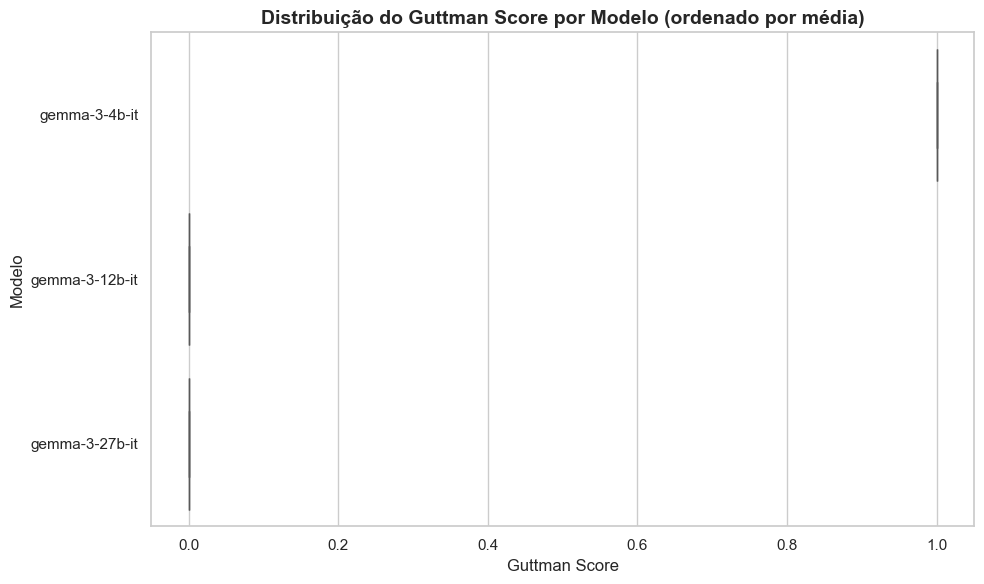

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a mediana do Guttman score por modelo
mean_order = (
    model_guttmann_df.groupby("model_name")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2. Plotar boxplot ordenado
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.boxplot(
    data=model_guttmann_df,
    y="model_name",
    x="n_inconsistencias",
    order=mean_order,      # ordena do maior pro menor
    palette="Set2",
    orient="h"               # horizontal pra melhor leitura
)

# 3. Ajustes visuais
plt.title("Distribuição do Guttman Score por Modelo (ordenado por média)", fontsize=14, weight='bold')
plt.xlabel("Guttman Score", fontsize=12)
plt.ylabel("Modelo", fontsize=12)
#plt.xlim(0.4, 1.1)  # intervalo pedido
plt.tight_layout()

plt.show()


In [123]:
# Mostra 'resposta_completa' quando 'alternativa' está vazia ou é NaN
question_long_df.loc[question_long_df['chosen_option'].isna(), 'full_response']


Series([], Name: full_response, dtype: object)

In [124]:
import pandas as pd

# Supondo que question_long_df já está carregado

# Cálculo da acurácia média por modelo e por firac
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
model_accuracy["model_order"] = range(1, len(model_accuracy) + 1)

firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
firac_accuracy["firac_order"] = range(1, len(firac_accuracy) + 1)

# Exibindo os resultados
print("Model order:")
print(model_accuracy)

print("\nFirac order:")
print(firac_accuracy)

model_order_accuracy = model_accuracy[["model_name"]].values
firac_order_accuracy = firac_accuracy[["firac"]].values




Model order:
       model_name  is_correct  model_order
0  gemma-3-12b-it         0.5            1
1   gemma-3-4b-it         0.5            2
2  gemma-3-27b-it         1.0            3

Firac order:
   firac  is_correct  firac_order
0  FI___    0.333333            1
1  F____    0.333333            2
2  FIR__    0.666667            3
3  _____    0.666667            4
4  FIRAC    1.000000            5
5  FIRA_    1.000000            6


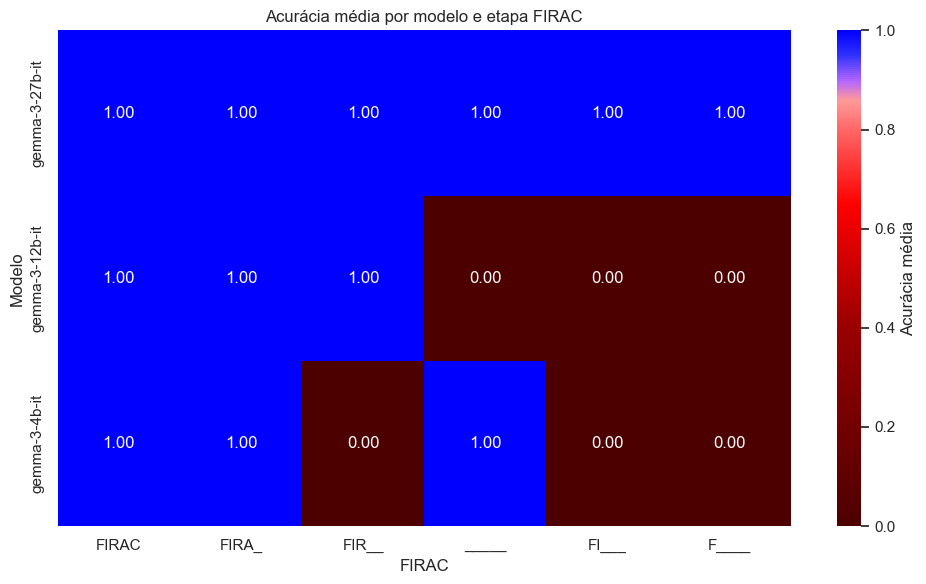

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Calcular acurácia média por modelo e firac
heatmap_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .unstack()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Reordenar DataFrame
heatmap_data = heatmap_data.loc[model_order_accuracy, firac_order_accuracy]

# 4. Colormap com nuances vermelhas e transição suave após 0.9
custom_cmap = LinearSegmentedColormap.from_list(
    "detailed_red_blue",
    [
        (0.0, "#4d0000"),   # 0.00 = vermelho muito escuro
        (0.4, "#990000"),   # 0.40 = vermelho forte
        (0.65, "#ff0000"),  # 0.65 = vermelho puro
        (0.80, "#ff6666"),  # 0.80 = vermelho claro
        (0.86, "#ff9999"),  # 0.86 = rosado
        (0.90, "#b366ff"),  # 0.90 = começa roxo
        (0.95, "#3333ff"),  # 0.95 = azul forte
        (1.0, "blue")       # 1.00 = azul puro
    ]
)

# 5. Plotar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Acurácia média'}
)
plt.title("Acurácia média por modelo e etapa FIRAC")
plt.xlabel("FIRAC")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


In [126]:
!pip install adjustText


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


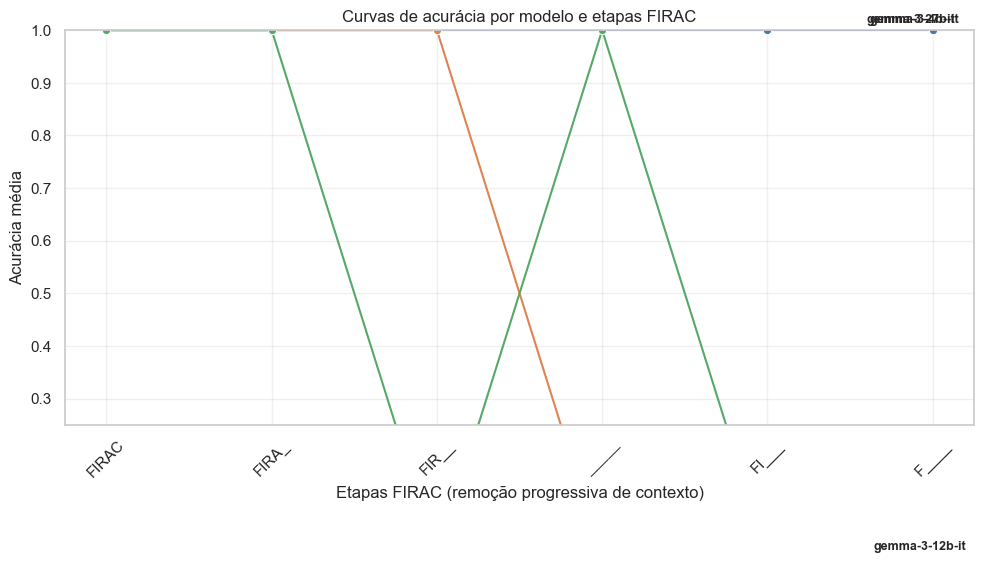

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Calcular acurácia média por modelo e firac
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# 4. Plotar as curvas sem legenda
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=curve_data,
    x="firac",
    y="is_correct",
    hue="model_name",
    hue_order=model_order_accuracy,
    marker="o",
    legend=False
)

# 5. Adicionar labels perto das curvas
texts = []
for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model]
    last_x = subset["firac"].iloc[-1]
    last_y = subset["is_correct"].iloc[-1]
    texts.append(
        plt.text(
            x=len(firac_order_accuracy) - 1,  # posição no eixo x
            y=last_y,
            s=model,
            fontsize=9,
            fontweight="bold"
        )
    )

# Ajustar automaticamente para evitar sobreposição
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# 6. Estilização
plt.title("Curvas de acurácia por modelo e etapas FIRAC")
plt.xlabel("Etapas FIRAC (remoção progressiva de contexto)")
plt.ylabel("Acurácia média")
plt.ylim(0.25, 1)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# -----------------------
# 1. Calcular acurácia média por modelo e firac
# -----------------------
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------
# 2. Calcular ordem dos modelos e FIRAC
# -----------------------
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# -----------------------
# 3. Garantir que as colunas sejam categóricas e ordenadas
# -----------------------
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# -----------------------
# 4. Calcular AUC (área sob a curva FIRAC) para cada modelo
# -----------------------
auc_df = []

for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model].sort_values("firac")
    # Como 'firac' é categórico, usamos índices numéricos igualmente espaçados
    x = np.arange(len(subset))
    y = subset["is_correct"].values
    auc_value = np.trapz(y, x) / (len(x) - 1)  # normalizar entre 0–1 se desejar
    
    # Calcular a acurácia original (firac == "_____")
    acc_original = (
        subset.loc[subset["firac"] == "____", "is_correct"]
        .values[0]
        if "____" in subset["firac"].values else np.nan
    )
    
    auc_df.append({
        "model_name": model,
        "acc_original": acc_original,
        "auc_firac": auc_value,
    })

auc_df = pd.DataFrame(auc_df)

# -----------------------
# 5. Calcular média e desvio-padrão de inconsistências (Guttman) por modelo
# -----------------------
gutmann_stats_df = (
    gutmann_long_df
    .groupby("model_name")["n_inconsistencias"]
    .agg(gutmann_avg_score="mean", gutmann_std_score="std")
    .reset_index()
)

# -----------------------
# 6. Fazer o join com auc_df
# -----------------------
auc_df = auc_df.merge(gutmann_stats_df, on="model_name", how="left")

# -----------------------
# 7. Ordenar pelo AUC (ou pelo Guttman médio, se preferir)
# -----------------------
auc_df = auc_df.sort_values("auc_firac", ascending=False).reset_index(drop=True)

auc_df.head(100)


,model_name,acc_original,auc_firac,gutmann_avg_score,gutmann_std_score
0,gemma-3-27b-it,NaN,1.0,0.0,NaN
1,gemma-3-12b-it,NaN,0.5,0.0,NaN
2,gemma-3-4b-it,NaN,0.5,1.0,NaN


In [129]:
auc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model_name         3 non-null      object 
 1   acc_original       0 non-null      float64
 2   auc_firac          3 non-null      float64
 3   gutmann_avg_score  3 non-null      float64
 4   gutmann_std_score  0 non-null      float64
dtypes: float64(4), object(1)
memory usage: 252.0+ bytes


C:\Users\pedro\AppData\Local\Temp\ipykernel_24804\3767733614.py:23: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, deg=2)


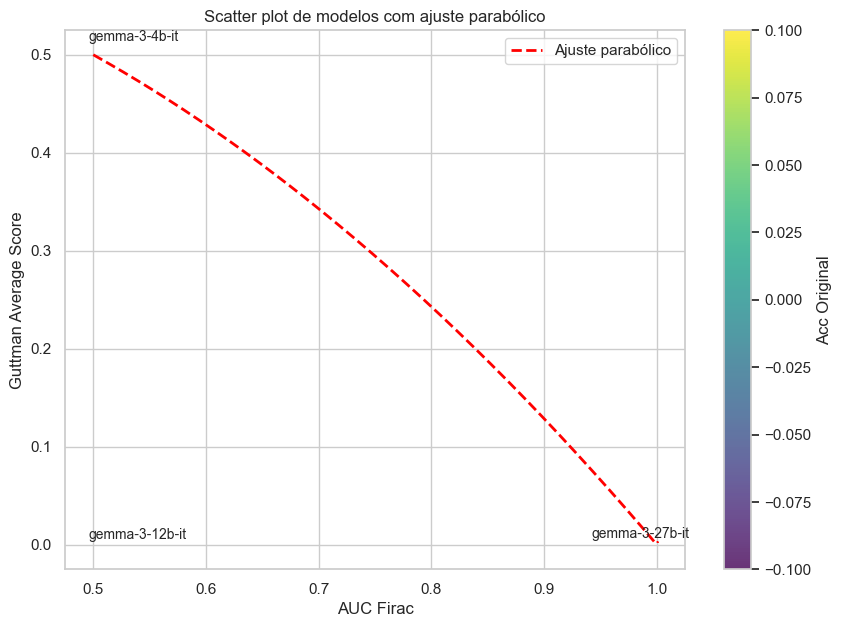

In [130]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

plt.figure(figsize=(10, 7))

# Dados
x = auc_df['auc_firac'].values
y = auc_df['gutmann_avg_score'].values

# Scatter plot
scatter = plt.scatter(
    x, 
    y, 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Ajuste de uma parábola (polinômio de grau 2)
coeffs = np.polyfit(x, y, deg=2)
parabola = np.poly1d(coeffs)

# Pontos para plotar a parábola
x_parab = np.linspace(x.min(), x.max(), 300)
y_parab = parabola(x_parab)

# Plotar a parábola
plt.plot(x_parab, y_parab, color='red', linestyle='--', linewidth=2, label='Ajuste parabólico')

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002
offset_y = 0.002
for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['auc_firac'] + offset_x,
            row['gutmann_avg_score'] + offset_y,
            row['model_name'],
            fontsize=10
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos, título e legenda
plt.xlabel('AUC Firac')
plt.ylabel('Guttman Average Score')
plt.title('Scatter plot de modelos com ajuste parabólico')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.legend()
plt.show()


LinAlgError: SVD did not converge in Linear Least Squares

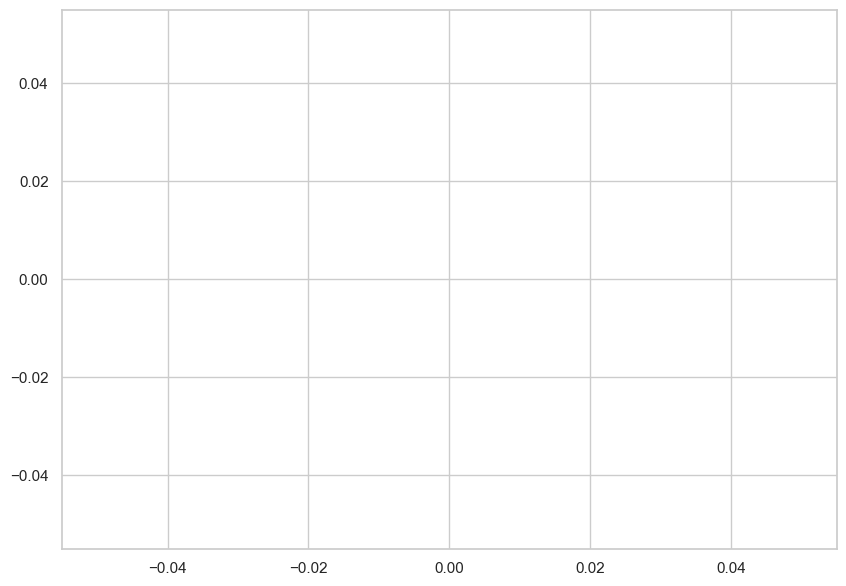

In [131]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

plt.figure(figsize=(10, 7))

# Dados
x = auc_df['acc_original'].values
y = auc_df['gutmann_avg_score'].values

# Scatter plot
scatter = plt.scatter(
    x, 
    y, 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Ajuste de uma parábola (polinômio de grau 2)
coeffs = np.polyfit(x, y, deg=2)
parabola = np.poly1d(coeffs)

# Pontos para plotar a parábola
x_parab = np.linspace(x.min(), x.max(), 300)
y_parab = parabola(x_parab)

# Plotar a parábola
plt.plot(x_parab, y_parab, color='red', linestyle='--', linewidth=2, label='Ajuste parabólico')

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002
offset_y = 0.002
for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['acc_original'] + offset_x,
            row['gutmann_avg_score'] + offset_y,
            row['model_name'],
            fontsize=10
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos, título e legenda
plt.xlabel('Acurácia Original')
plt.ylabel('Guttman Average Score')
plt.title('Scatter plot de modelos com ajuste parabólico')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10, 7))

# Scatter plot
scatter = plt.scatter(
    auc_df['acc_original'], 
    auc_df['auc_firac'], 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002  # ajuste horizontal (direita)
offset_y = 0.002  # ajuste vertical (para cima)

for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['acc_original'] + offset_x, 
            row['auc_firac'] + offset_y, 
            row['model_name'], 
            fontsize=10
        )
    )

# Ajustar texto para não sobrepor
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos e título
plt.xlabel('Acurácia Original')
plt.ylabel('AUC Firac')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular média de inconsistências por questão
question_order = (
    gutmann_long_df
    .groupby("question_id")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)  # do maior para o menor
    .index
)

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Boxplot de inconsistências por questão, ordenado pela média
sns.boxplot(
    data=gutmann_long_df,
    x="question_id",
    y="n_inconsistencias",
    order=question_order,
    color="skyblue"
)

plt.title("Distribuição do número de inconsistências por question_id (ordenado pela média)", fontsize=14, weight="bold")
plt.xlabel("Question ID", fontsize=12)
plt.ylabel("Número de inconsistências", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# -----------------------
# 1. Transformar para wide format
# -----------------------
# 1. Calcular acurácia média por modelo e firac]

curve_data = (
    question_long_df
    .groupby(["question_id", "firac"])["is_correct"]
    .mean()
    .reset_index()
)


curve_wide = curve_data.pivot(index="question_id", columns="firac", values="is_correct").fillna(0)


# -----------------------
# 2. Clusterizar as curvas semelhantes
# -----------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(curve_wide)

curve_data = curve_data.merge(
    pd.DataFrame({"question_id": curve_wide.index, "cluster": clusters}),
    on="question_id"
)

model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()


# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)


#curve_data = curve_data.merge(curve_wide["cluster"], on="question_id")


# -----------------------
# 3. Reordenar os clusters com base na média de is_correct
# -----------------------
cluster_means = (
    curve_data.groupby("cluster")["is_correct"]
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order = {old: new for new, old in enumerate(cluster_means["cluster"])}
curve_data["cluster"] = curve_data["cluster"].map(cluster_order)

# -----------------------
# 4. Função para plotar curvas individuais + média
# -----------------------
def plot_cluster_data(data, **kwargs):
    sns.lineplot(
        data=data,
        x="firac", y="is_correct",
        hue="question_id",
        alpha=0.4, lw=1, legend=False
    )
    mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
    sns.lineplot(
        data=mean_curve,
        x="firac", y="is_correct",
        color="black", lw=3
    )

# -----------------------
# 5. Visualizar clusters individualmente (FacetGrid)
# -----------------------
g = sns.FacetGrid(
    curve_data,
    col="cluster",
    col_wrap=3,
    height=3,
    sharey=True
)
g.map_dataframe(plot_cluster_data)
g.set_titles("Cluster {col_name}")

# Rotacionar labels do eixo X
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# -----------------------
# 6. Novo gráfico: curvas médias dos 3 clusters com erro padrão
# -----------------------

# Calcular média e erro padrão por cluster e firac
summary = (
    curve_data.groupby(["cluster", "firac"])["is_correct"]
    .agg(["mean", "sem"])  # sem = standard error of the mean
    .reset_index()
)

# Plotar todas as curvas juntas
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=summary,
    x="firac", y="mean",
    hue="cluster",
    linewidth=2.5,
    err_style="band",
    err_kws={"alpha": 0.2},
)

# Adicionar bandas de erro manualmente (para mais controle visual)
for cluster_id, cluster_df in summary.groupby("cluster"):
    plt.fill_between(
        cluster_df["firac"],
        cluster_df["mean"] - cluster_df["sem"],
        cluster_df["mean"] + cluster_df["sem"],
        alpha=0.2
    )

plt.title("Clusters de questões por perfil cognitivo")
plt.xlabel("FIRAC")
plt.ylabel("Acurácia")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

question_cluster_df = curve_data[["question_id", "cluster"]].drop_duplicates().reset_index(drop=True)



In [ ]:
question_cluster_df.head()

In [ ]:
# -----------------------
# Merge question_agg_df com question_cluster_df
# -----------------------
question_summary_df = question_agg_df.merge(
    question_cluster_df,
    on="question_id",
    how="left"
)

# Visualizar as primeiras linhas
question_summary_df.tail()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. Definir as colunas a analisar
# -----------------------
cols_to_plot = ["accuracy", "question_body_length", "rule_count", "response_time_seconds"]

# -----------------------
# 2. Criar os boxplots
# -----------------------
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=question_summary_df, x="cluster", y=col)
    plt.title(f"Distribuição de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()

plt.show()


In [ ]:
# 1. Calcular acurácia média por combinação model_name + firac
accuracy_order = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .sort_values(ascending=True)
)

# 2. Pivotar para o formato wide
question_wide_df = (
    question_long_df
    .pivot_table(
        index="question_id",
        columns=["model_name", "firac"],
        values="is_correct"
    )
)

# 3. Reordenar as colunas conforme a acurácia calculada
question_wide_df = question_wide_df[accuracy_order.index]

# 4. Flatten do MultiIndex nas colunas
question_wide_df.columns = [
    f"{model}_{firac}" for model, firac in question_wide_df.columns
]

# 5. Resetar o índice (opcional)
question_wide_df = question_wide_df.reset_index()

#question_wide_df = question_wide_df.dropna(axis=1, how="any")

question_wide_df.head()


In [ ]:
pd.set_option('display.max_rows', None)


# Conta o número de valores NaN por coluna
na_counts = question_wide_df.isna().sum()

# Mostra o resultado ordenado do maior para o menor
na_counts.sort_values(ascending=False)

In [ ]:
# Mantém apenas as colunas que começam com 'gemini'
question_wide_df = question_wide_df.filter(regex=r'^gemini')

# Verifica o resultado
question_wide_df.head()
question_wide_df = question_wide_df.dropna()

question_wide_df.head()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

pd.set_option('display.max_columns', None)


# 1. Separar apenas as colunas numéricas
X = question_wide_df.select_dtypes(include="number")

# 2. Definir o número de clusters
n_clusters = 2

# 3. Rodar o K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
question_wide_df["cluster"] = kmeans.fit_predict(X)

# 4. Criar um DataFrame dos centróides
cluster_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(n_clusters)]
)

# 5. Adicionar uma coluna com o tamanho de cada cluster
cluster_sizes = question_wide_df["cluster"].value_counts().sort_index()
cluster_df["size"] = cluster_sizes.values

# 6. Mostrar o resultado arredondado para melhor visualização
cluster_df = cluster_df.round(3)
cluster_df.head()


In [ ]:
import pandas as pd
import numpy as np

# 1. Criar matriz: linhas = provas (ou observações), colunas = question_id, valores = is_correct
#    Se quisermos alpha para todo o exame, podemos agregar por prova ou usar todas as respostas juntas.
exam_matrix = question_long_df.pivot_table(
    index='pdf_filename',       # ou outro identificador de observação
    columns='question_id',
    values='is_correct'
)

# 2. Função para calcular alpha de Cronbach
def cronbach_alpha(df):
    df = df.dropna(axis=1, how='all')  # remover colunas sem dados
    k = df.shape[1]                     # número de itens
    item_var = df.var(axis=0, ddof=1)   # variância de cada item
    total_var = df.sum(axis=1).var(ddof=1)  # variância total da soma
    alpha = (k / (k-1)) * (1 - item_var.sum() / total_var)
    return alpha

# 3. Calcular alpha
alpha_exam = cronbach_alpha(exam_matrix)
print("Alpha de Cronbach do exame:", alpha_exam)
